# LC-oscillator chain (Section 4.2)

**Energy-Consistent Splitting Methods for Port-Hamiltonian ODEs via a Generalized Extended State Space Approach**

Kevin Schaefers, Andreas Bartel, Michael Guenther (University of Wuppertal)

This notebook reproduces the numerical experiments of Section 4.2 of the paper.
The methods and the benchmark problem are defined there; the implementation is contained in the package `essph`.

In [1]:
import sys

sys.path.append("..")  # make the package importable when running from notebooks/

import matplotlib.pyplot as plt
import numpy as np

from essph import (
    current_source,
    discrete_l2_error,
    ead,
    ess,
    gl1,
    gl2,
    reference_solution,
    setup_lc_chain_benchmark,
)

tspan = [0, 8e-3]

## Figure 4: reference solution for $N = 3$

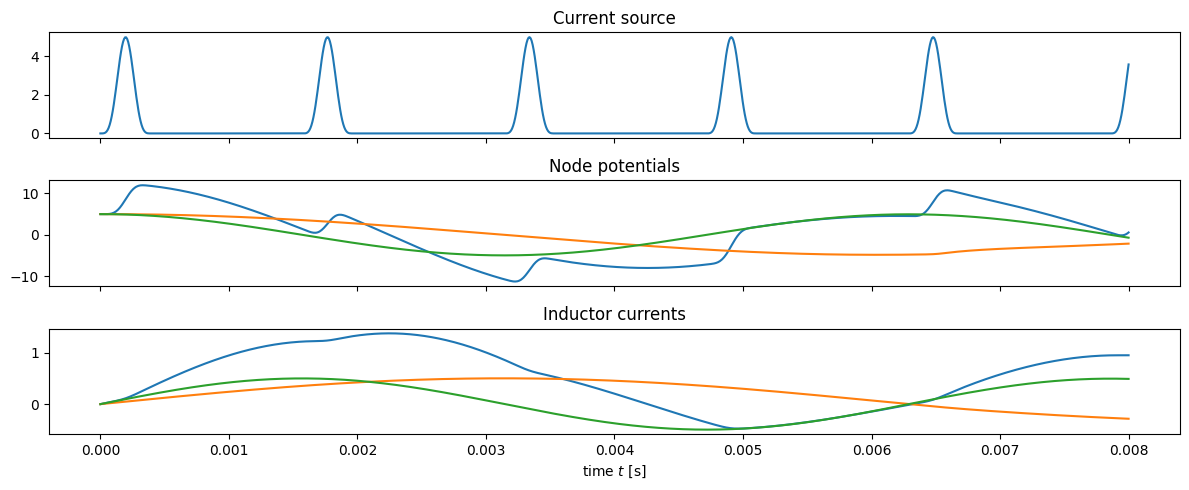

In [2]:
system, x0 = setup_lc_chain_benchmark(3)
sol = reference_solution(system, x0, tspan)

t = np.linspace(tspan[0], tspan[1], 1000)
x_ref = sol.sol(t)
i_values = np.array([current_source(t_eval) for t_eval in t])

fig, axs = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
axs[0].plot(t, i_values)
axs[0].set_title("Current source")
axs[1].plot(t, x_ref[0::2].T)
axs[1].set_title("Node potentials")
axs[2].plot(t, x_ref[1::2].T)
axs[2].set_title("Inductor currents")
axs[2].set_xlabel(r"time $t$ [s]")
fig.tight_layout()
plt.show()

## Figure 5 and Table 1: convergence and computational effort for $N = 50$

Errors below `REF_ACC` are limited by the accuracy of the reference solution and are not shown.

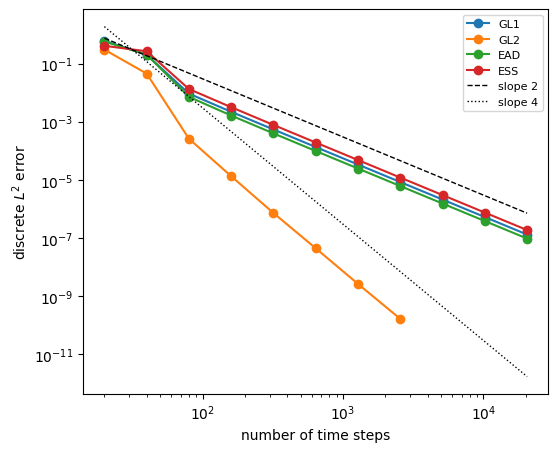

GL1  observed orders: [1.6  4.44 2.08 2.02 2.01 2.   2.   2.   2.   2.  ]
GL2  observed orders: [2.74 7.44 4.28 4.21 4.03 4.07 3.99 3.62 0.65 0.01]
EAD  observed orders: [1.5  4.82 2.14 2.04 2.01 2.   2.   2.   2.   2.  ]
ESS  observed orders: [0.63 4.31 2.08 2.03 2.01 2.   2.   2.   2.   2.  ]

method    factorizations    Newton its     R evaluations
GL1         1.00-1.00     2.85-9.60         3.85-10.60  
GL2         1.00-1.00     2.72-5.95         6.44-12.90  
EAD         1.00-1.00     2.31-9.20         3.31-10.20  
ESS         2.00-2.05     0.00-0.00         2.00-2.05   


In [3]:
system, x0 = setup_lc_chain_benchmark(50)
sol = reference_solution(system, x0, tspan)

nsteps_list = np.array([20 * 2**k for k in range(11)])
methods = {"GL1": gl1, "GL2": gl2, "EAD": ead, "ESS": ess}
REF_ACC = 1e-10

l2_error = {name: np.zeros(len(nsteps_list)) for name in methods}
effort = {name: [] for name in methods}

for i, nsteps in enumerate(nsteps_list):
    for name, method in methods.items():
        result = method(system, x0, tspan, nsteps)
        t, x, stats = result[0], result[1], result[-1]  # for ESS, result[1] is the component v
        l2_error[name][i] = discrete_l2_error(sol, t, x)
        effort[name].append(stats)

plt.figure(figsize=(6, 5))
for name in methods:
    mask = l2_error[name] > REF_ACC
    plt.loglog(nsteps_list[mask], l2_error[name][mask], marker="o", label=name)
plt.loglog(nsteps_list, 3e2 / nsteps_list**2, "k--", lw=1, label="slope 2")
plt.loglog(nsteps_list, 3e5 / nsteps_list**4, "k:", lw=1, label="slope 4")
plt.xlabel("number of time steps")
plt.ylabel(r"discrete $L^2$ error")
plt.legend(fontsize=8)
plt.show()

for name in methods:
    print(f"{name:4s} observed orders:", np.round(np.log2(l2_error[name][:-1] / l2_error[name][1:]), 2))

print()
print(f"{'method':8s}{'factorizations':>16s}{'Newton its':>14s}{'R evaluations':>18s}")
for name in methods:
    stats = effort[name]
    fac = [s.factorizations_per_step for s in stats]
    its = [s.newton_iterations_per_step for s in stats]
    r_ev = [s.R_evaluations_per_step for s in stats]
    print(f"{name:8s}{min(fac):8.2f}-{max(fac):<7.2f}{min(its):6.2f}-{max(its):<7.2f}"
          f"{min(r_ev):10.2f}-{max(r_ev):<7.2f}")

## Figure 6: energy behavior of `ESS` for $N = 50$ with $h = 10^{-4}$

Left: with current source, energy error with respect to the reference solution.
Right: without current source, discrete energy rate.

with source:    max |H(v_n) - H(x(t_n))| = 3.72e-04, max |H(w_n) - H(x(t_n))| = 2.28e-04
without source: max_n [H(v_n+1) - H(v_n)] = 1.39e-17, max_n [H(w_n+1) - H(w_n)] = 6.94e-17


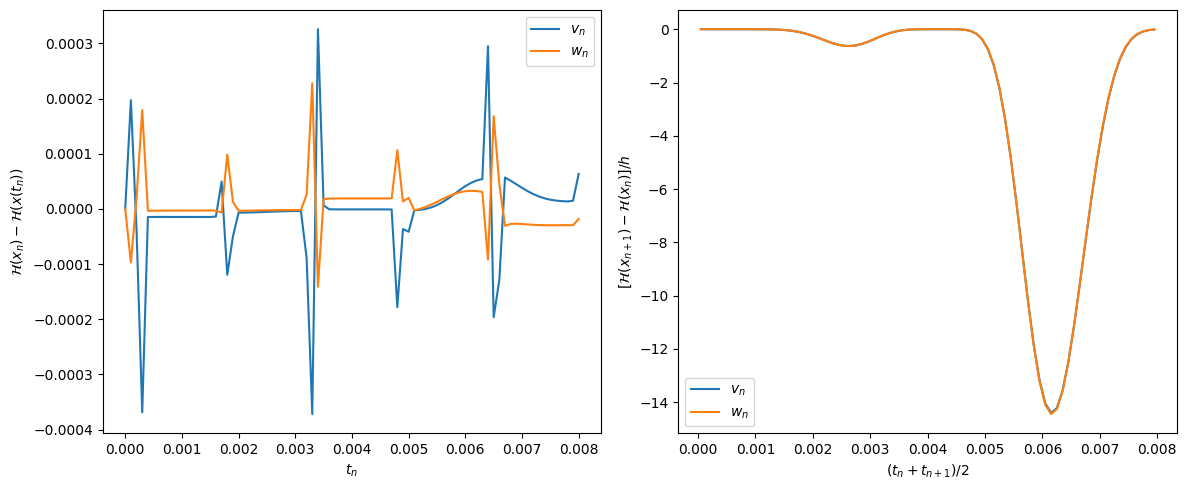

In [4]:
nsteps = 80
h = (tspan[1] - tspan[0]) / nsteps
fig, (ax_source, ax_closed) = plt.subplots(1, 2, figsize=(12, 5))

system, x0 = setup_lc_chain_benchmark(50, with_source=True)
sol = reference_solution(system, x0, tspan)
t, v, w, _ = ess(system, x0, tspan, nsteps)
x_ref = sol.sol(t)

H_ref = np.array([system.H(x_ref[:, n]) for n in range(nsteps + 1)])
H_v = np.array([system.H(v[:, n]) for n in range(nsteps + 1)])
H_w = np.array([system.H(w[:, n]) for n in range(nsteps + 1)])
ax_source.plot(t, H_v - H_ref, label=r"$v_n$")
ax_source.plot(t, H_w - H_ref, label=r"$w_n$")
ax_source.set_xlabel(r"$t_n$")
ax_source.set_ylabel(r"$\mathcal{H}(x_n) - \mathcal{H}(x(t_n))$")
ax_source.legend()
print(f"with source:    max |H(v_n) - H(x(t_n))| = {np.max(np.abs(H_v - H_ref)):.2e}, "
      f"max |H(w_n) - H(x(t_n))| = {np.max(np.abs(H_w - H_ref)):.2e}")

system, x0 = setup_lc_chain_benchmark(50, with_source=False)
t, v, w, _ = ess(system, x0, tspan, nsteps)

H_v = np.array([system.H(v[:, n]) for n in range(nsteps + 1)])
H_w = np.array([system.H(w[:, n]) for n in range(nsteps + 1)])
t_mid = (t[1:] + t[:-1]) / 2
ax_closed.plot(t_mid, np.diff(H_v) / h, label=r"$v_n$")
ax_closed.plot(t_mid, np.diff(H_w) / h, label=r"$w_n$")
ax_closed.set_xlabel(r"$(t_n + t_{n+1})/2$")
ax_closed.set_ylabel(r"$[\mathcal{H}(x_{n+1}) - \mathcal{H}(x_n)]/h$")
ax_closed.legend()
print(f"without source: max_n [H(v_n+1) - H(v_n)] = {np.max(np.diff(H_v)):.2e}, "
      f"max_n [H(w_n+1) - H(w_n)] = {np.max(np.diff(H_w)):.2e}")

fig.tight_layout()
plt.show()